In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [15]:
config_path = '../configs/config_pbc.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [16]:
config['axis'] = 1

In [17]:
task = config['dataset_name']
task

'pbc2'

In [18]:
agent = LambdaSA(config, 42)

In [19]:
seqs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = seqs.shape
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [20]:
test_size = 0.2
size = int(n * (1-test_size))
size

249

In [21]:
seqs.shape

(312, 16, 15)

In [22]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
        (idx_train, idx_valid)
    )

In [23]:
%%time

sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 

res2_is = np.zeros((n_folds, len(sizes)))
res2_lm = np.zeros((n_folds, len(sizes)))
res2_td = np.zeros((n_folds, len(sizes)))
res2_dtd = np.zeros((n_folds, len(sizes)))

res3_is = np.zeros((n_folds, len(sizes)))
res3_lm = np.zeros((n_folds, len(sizes)))
res3_td = np.zeros((n_folds, len(sizes)))
res3_dtd = np.zeros((n_folds, len(sizes)))

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v), (i_tr, i_val) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        config['axis'] = 1
        
        # Initial state.
        model = LambdaSA(config, 42)
        model.train(seqs_t[:size], ts_t[:size], cs_t[:size])
        sc_v = model.survival_curve(seqs_v)
        res2_is[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v)
        scores = model.scores(seqs_v[:,0], q=0.0)
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Landmarking.
        model = LambdaSA(config, 42)
        model.lambda_ = 1.0
        model.train(seqs_, ts_, cs_)
        sc_v = model.survival_curve(seqs_v)
        res2_lm[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v)
        scores = model.scores(seqs_v[:,0], q=0.0)
        res3_lm[fold, i] =concordance_index(scores, ts_v, cs_v)
        
        # Temporal difference.
        model = LambdaSA(config, 42)
        model.lambda_ = 0.0
        model.train(seqs_, ts_, cs_)
        sc_v = model.survival_curve(seqs_v)
        res2_td[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v)
        scores = model.scores(seqs_v[:,0], q=0.0)
        res3_td[fold, i] = concordance_index(scores, ts_v, cs_v)

        # Deep TD
        config['axis'] = 2
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = 0.0

        seq_tr = model.data['seqs'][i_tr][:size]
        seq_val = model.data['seqs'][i_val]
        ts_tr = model.data['ts'][i_tr][:size]
        ts_val = model.data['ts'][i_val]
        cs_tr = model.data['cs'][i_tr][:size]
        cs_val = model.data['cs'][i_val]
        ys_tr = model.data['target'][i_tr][:size]
        ys_val = model.data['target'][i_val]
        m_tr = model.data['mask'][i_tr][:size]
        m_val = model.data['mask'][i_val]
        h_tr = model.data['h_ws'][i_tr][:size]
        h_val = model.data['h_ws'][i_val]

        assert np.all(seq_tr == seqs_t[:size])
        assert np.all(seq_val == seqs_v)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seq_tr
        train_gen.ts = ts_tr
        train_gen.cs = cs_tr
        train_gen.y = ys_tr
        train_gen.mask = m_tr
        train_gen.h_ws = h_tr

        _ = model.train(train_gen)
        surv = model.survival_curve(seq_val)
        res2_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_val, cs_val)
        scores = model.scores(seq_val, q=0.0)
        res3_dtd[fold, i] = concordance_index(scores, ts_val, cs_val)
        
    print()

....
....
....
....
....
CPU times: user 34.4 s, sys: 3.69 s, total: 38.1 s
Wall time: 33.2 s


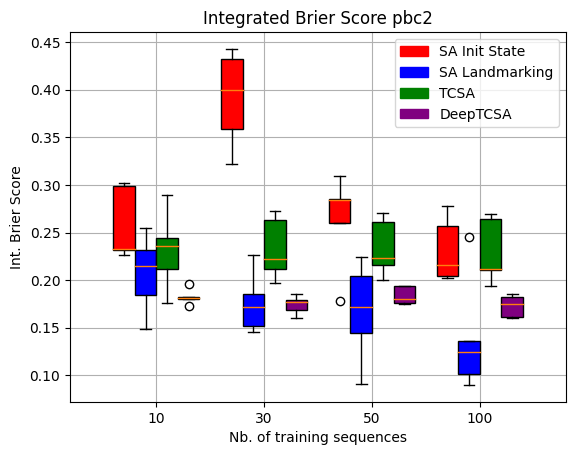

In [24]:
save_fig = False

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, res2_is, 'SA Init State'), 
                  (1, res2_lm, 'SA Landmarking'),
                  (2, res2_td, 'TCSA'),
                  (3, res2_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='upper right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Int. Brier Score')
ax.set_title('Integrated Brier Score {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Int_brier_score.pdf".format(task), format="pdf")

plt.show()

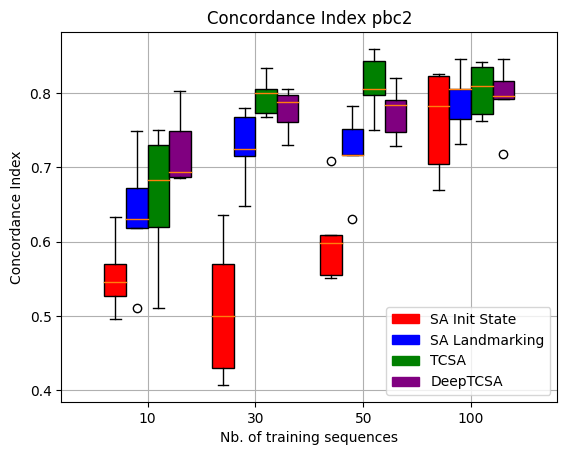

In [25]:

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, res3_is, 'SA Init State'), 
                  (1, res3_lm, 'SA Landmarking'),
                  (2, res3_td, 'TCSA'),
                  (3, res3_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='lower right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Concordance Index')
ax.set_title('Concordance Index {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Concordance_idx.pdf".format(task), format="pdf")

plt.show()

In [123]:
np.median(res3_is, axis=0)

array([0.45651224, 0.58874836, 0.65713066, 0.64675052])

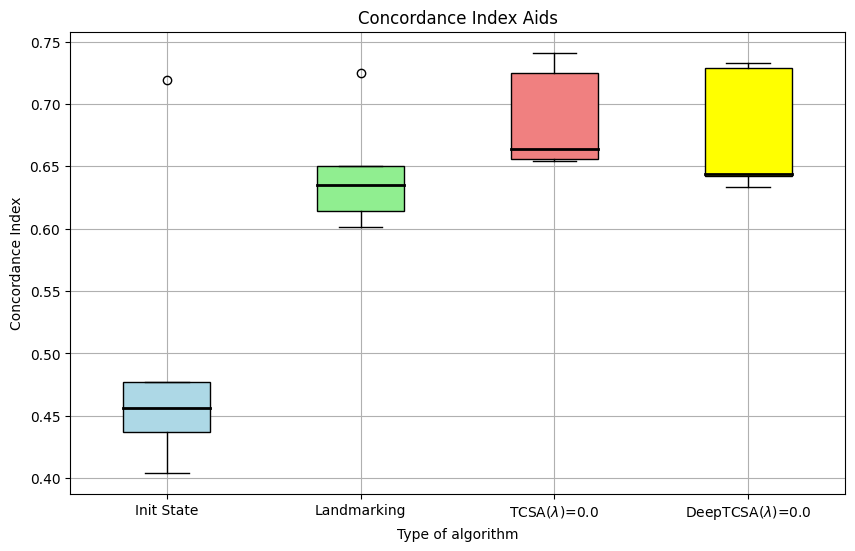

In [124]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = res3_is[:, 0].reshape(-1)
bs_lm = res3_lm[:, 0].reshape(-1)
bs_a9 = res3_td[:, 0].reshape(-1)
bs_a0 = res3_dtd[:, 0].reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a9, bs_a0], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking', r'TCSA($\lambda$)=0.0', r'DeepTCSA($\lambda$)=0.0'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index Aids")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/lastfm/Int_brier_score_task_transformer_static.pdf", format="pdf")

plt.show()


In [30]:
beta = model.state.params['cox_linear_model']['beta']
scores = score(beta, seqs_v[:, 0])

In [31]:
concordance_index(scores, ts_v, cs_v)

0.6620148277365896

In [32]:
scores = model.scores(seqs_v[:,0], q=0)
concordance_index(scores, ts_v, cs_v)

0.6620148277365896